In [ ]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [ ]:
#2. Load Dataset
df = pd.read_csv("zomato.csv")


In [ ]:

#3. Data Validation
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
print(df.info())


Shape of dataset: (51717, 17)

Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   re

In [ ]:

#4. Data Cleaning

# Remove duplicates
df = df.drop_duplicates()

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Handle missing values 
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])


In [8]:

#5. Create Date-Time Column (Synthetic - Required for analysis)
df['order_datetime'] = pd.to_datetime(
    np.random.choice(pd.date_range(start='2023-01-01', end='2023-12-31', freq='h'), size=len(df))
)


In [9]:
#6. Extract Date-Time Components
df['hour'] = df['order_datetime'].dt.hour
df['day'] = df['order_datetime'].dt.day
df['month'] = df['order_datetime'].dt.month
df['weekday'] = df['order_datetime'].dt.day_name()


In [10]:

#7. Create Delivery Time Column (Synthetic)
df['delivery_time'] = np.random.randint(20, 60, size=len(df))


In [12]:

#8. Performance Metrics
total_orders = len(df)
avg_delivery = df['delivery_time'].mean()
max_delivery = df['delivery_time'].max()
min_delivery = df['delivery_time'].min()

print("\n--- Performance Metrics ---")
print("Total Orders:", total_orders)
print("Average Delivery Time:", avg_delivery)
print("Max Delivery Time:", max_delivery)
print("Min Delivery Time:", min_delivery)



--- Performance Metrics ---
Total Orders: 51717
Average Delivery Time: 39.49507898756695
Max Delivery Time: 59
Min Delivery Time: 20


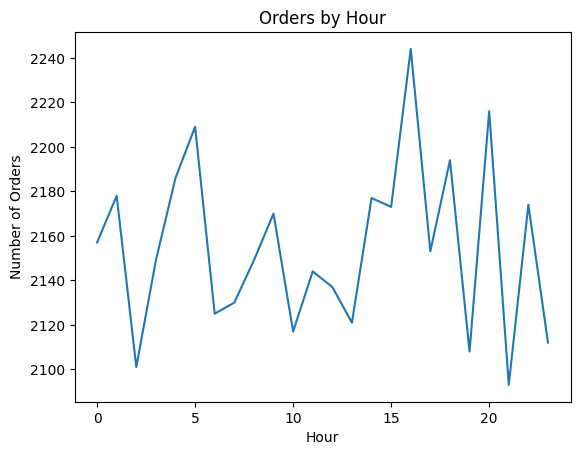

In [13]:
#9. Peak Demand Analysis

# Orders by Hour (Line Chart)
orders_by_hour = df.groupby('hour').size()
plt.figure()
plt.plot(orders_by_hour)
plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.show()



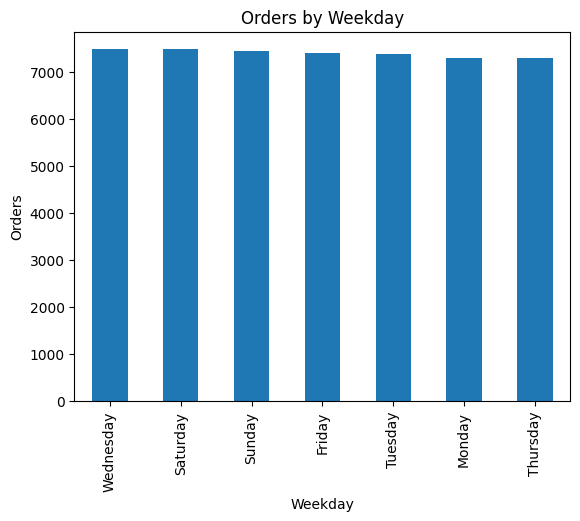

In [14]:
# Orders by Weekday (Bar Chart)
plt.figure()
df['weekday'].value_counts().plot(kind='bar')
plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Orders")
plt.show()



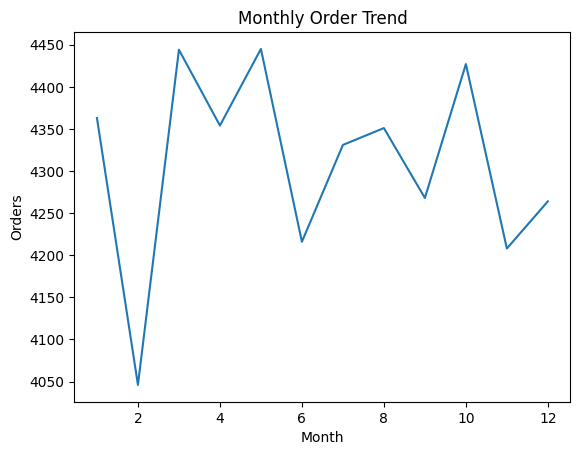

In [15]:
# Monthly Trend (Line Chart)
plt.figure()
df.groupby('month').size().plot()
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()



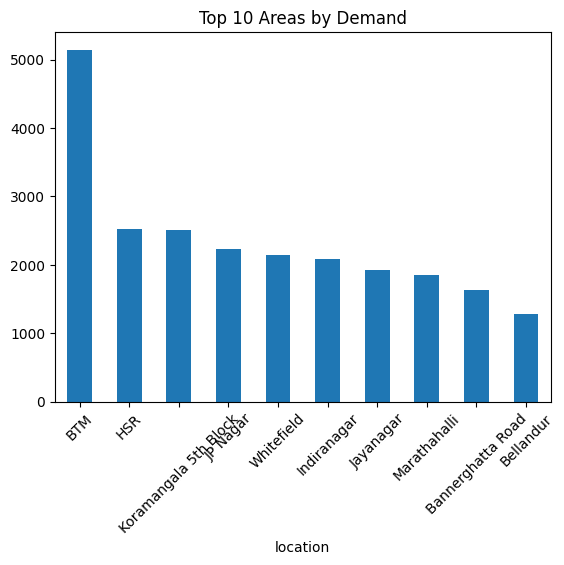

In [16]:

#10. Area-Wise Demand Analysis

# Top Areas by Demand
plt.figure()
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Areas by Demand")
plt.xticks(rotation=45)
plt.show()



In [17]:
# Area-wise Average Delivery Time
area_delivery = df.groupby('location')['delivery_time'].mean().sort_values(ascending=False).head(10)
print("\nTop Areas with Highest Avg Delivery Time:")
print(area_delivery)




Top Areas with Highest Avg Delivery Time:
location
Mysore Road          44.454545
Kengeri              43.333333
Central Bangalore    43.250000
Old Madras Road      42.863636
Nagarbhavi           42.777778
Jakkur               42.000000
Vijay Nagar          41.650000
Uttarahalli          41.176471
Sankey Road          41.074074
Infantry Road        41.059603
Name: delivery_time, dtype: float64


In [18]:
#11. Bottleneck Detection

# High Delay Areas (>50 minutes)
high_delay = df[df['delivery_time'] > 50]
print("\nHigh Delay Areas:")
print(high_delay['location'].value_counts().head(10))

# Peak Hour Delays
delay_by_hour = df.groupby('hour')['delivery_time'].mean()
print("\nPeak Hour Delays:")
print(delay_by_hour.sort_values(ascending=False).head())




High Delay Areas:
location
BTM                      1177
HSR                       579
Koramangala 5th Block     543
JP Nagar                  538
Whitefield                521
Jayanagar                 479
Indiranagar               432
Marathahalli              418
Bannerghatta Road         368
Koramangala 1st Block     301
Name: count, dtype: int64

Peak Hour Delays:
hour
1     40.257576
16    39.976827
7     39.666667
4     39.625343
19    39.609108
Name: delivery_time, dtype: float64


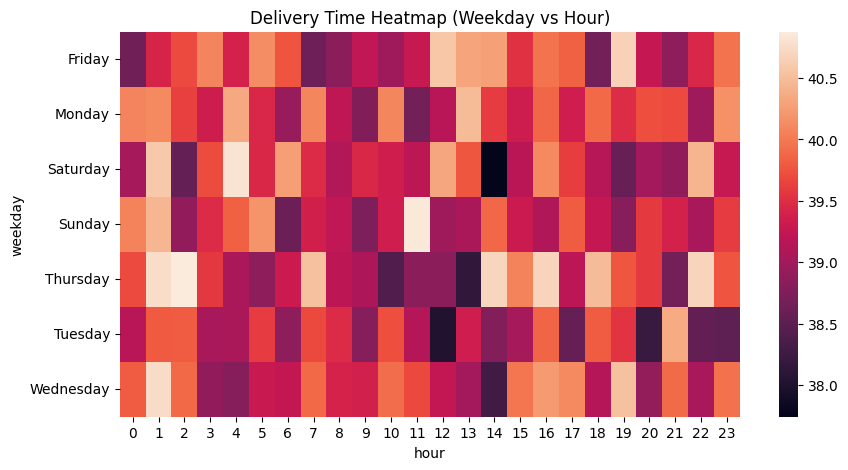

In [20]:
#12. Heatmap (Hour vs Weekday)
pivot = df.pivot_table(index='weekday', columns='hour', values='delivery_time')

plt.figure(figsize=(10,5))
sns.heatmap(pivot)
plt.title("Delivery Time Heatmap (Weekday vs Hour)")
plt.show()


In [21]:
# ================================
#  Project Completed Successfully
# ================================